In [44]:
from matplotlib import pyplot as plt
import numpy as np
import json

In [ ]:
filename = "results_EM_MWGP_test-flight"

In [ ]:
with open(f"results/{filename}.json", "r") as f:
    results = json.load(f)

# plot true vs estimated values for mu, eta, nu, and Theta, with MSE as error bars. Each plot should be a separate figure.
mu_true = np.array(results["mu"]["true"])
mu_est = np.array(results["mu"]["estimated"])
eta_true = np.array(results["eta"]["true"])
eta_est = np.array(results["eta"]["estimated"])
nu_true = np.array(results["nu"]["true"])
nu_est = np.array(results["nu"]["estimated"])
Theta_true = np.array(results["Theta"]["true"])
Theta_est = np.array(results["Theta"]["estimated"])
mse_mu = np.array(results["mu"]["mse"])
mse_eta = np.array(results["eta"]["mse"])
mse_nu = np.array(results["nu"]["mse"])
mse_Theta = results["Theta"]["mse"]

p = len(mu_true)

In [47]:
print(f"{'mu':>10} {np.round(mu_true, 5)} {np.round(mu_est, 5)}")
print(f"{'eta':>10} {np.round(eta_true, 5)} {np.round(eta_est, 5)}")
print(f"{'nu':>10} {np.round(nu_true, 5)} {np.round(nu_est, 5)}")
print(f"{'gamma':>10} {np.round(eta_true * nu_true, 5)} {np.round(eta_est * nu_est, 5)}")
print(f"{'mu + gamma:':>10} {np.round(mu_true + eta_true * nu_true, 5)} {np.round(mu_est + eta_est * nu_est, 5)}")
print("\nTrue Theta:\n", np.round(Theta_true, 5))
print("\nEstimated Theta:\n", np.round(Theta_est, 5))
print("\n")
print("Mean squared error for mu:", mse_mu)
print("Mean squared error for nu:", mse_nu)
print("Mean squared error for eta:", mse_eta)
print("Mean squared error for Theta:", mse_Theta)

        mu [0.27948 0.20695 0.20649 0.7779  0.17981] [0.27932 0.2887  0.20895 0.81311 0.24218]
       eta [ 0.19086  0.61799 -0.9614  -0.78831  0.57338] [ 0.05174  0.11381 -0.97923 -0.76725  0.34205]
        nu [0.27948 0.20695 0.20649 0.7779  0.17981] [0.27932 0.2887  0.20895 0.81311 0.24218]
     gamma [ 0.05334  0.12789 -0.19851 -0.61323  0.1031 ] [ 0.01445  0.03286 -0.20461 -0.62386  0.08284]
mu + gamma: [0.33282 0.33485 0.00797 0.16467 0.2829 ] [0.29378 0.32156 0.00434 0.18925 0.32502]

True Theta:
 [[2.  0.5 0.  0.  0. ]
 [0.5 2.  0.5 0.  0. ]
 [0.  0.5 2.  0.5 0. ]
 [0.  0.  0.5 2.  0.5]
 [0.  0.  0.  0.5 2. ]]

Estimated Theta:
 [[ 1.9512   0.53756  0.       0.04067  0.01443]
 [ 0.53756  2.07546  0.5176  -0.0655   0.00326]
 [ 0.       0.5176   1.96756  0.40558  0.01506]
 [ 0.04067 -0.0655   0.40558  2.01031  0.43545]
 [ 0.01443  0.00326  0.01506  0.43545  1.99498]]


Mean squared error for mu: [2.39128268e-08 6.68298301e-03 6.08415067e-06 1.23994800e-03
 3.89054420e-03]
Mean sq

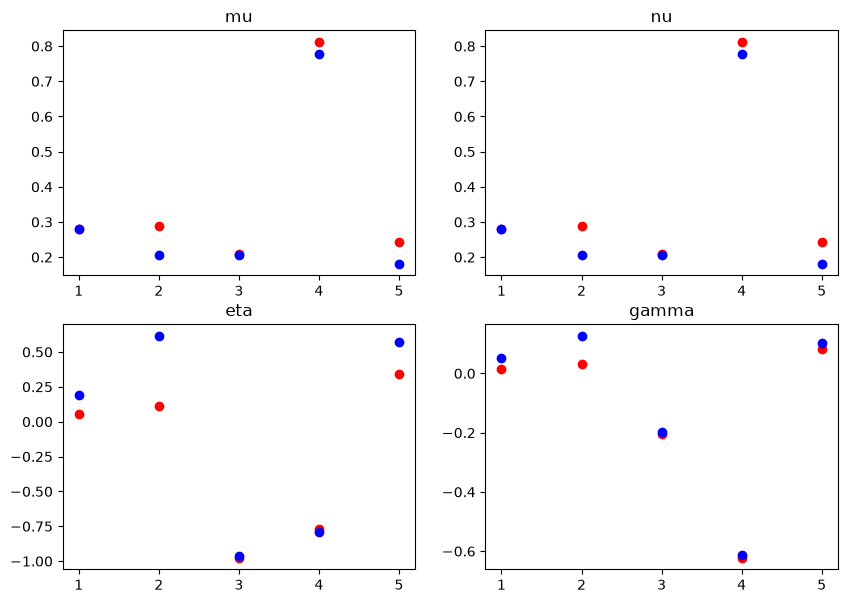

In [48]:
# Create a plot with 4 subfigures
fig, axs = plt.subplots(2, 2, figsize = (10,7))
axs[0, 0].scatter(range(p), mu_est, color='red', label='Estimated mu')
axs[0, 0].scatter(range(p), mu_true, color='blue', label='True mu')
axs[0, 0].set_xticks(range(p), range(1, p+1))
axs[0, 0].set_title('mu')

axs[0, 1].scatter(range(p), nu_est, color='red', label='Estimated nu')
axs[0, 1].scatter(range(p), nu_true, color='blue', label='True nu')
axs[0, 1].set_xticks(range(p), range(1, p+1))
axs[0, 1].set_title('nu')

axs[1, 0].scatter(range(p), eta_est, color='red', label='Estimated eta')
axs[1, 0].scatter(range(p), eta_true, color='blue', label='True eta')
axs[1, 0].set_xticks(range(p), range(1, p+1))
axs[1, 0].set_title('eta')

axs[1, 1].scatter(range(p), nu_est * eta_est, color='red', label='Estimated gamma')
axs[1, 1].scatter(range(p), nu_true * eta_true, color='blue', label='True gamma')
axs[1, 1].set_xticks(range(p), range(1, p+1))
axs[1, 1].set_title('gamma')

fig.savefig(f"results/{filename}.pdf")

In [49]:
# # make a p by p heatmap for Theta, where the intensity of the color represents the difference between the true and estimated values, with a colorbar to indicate the scale of the difference.
# plt.figure()
# plt.imshow(np.abs(Theta_true - Theta_est), cmap='viridis', interpolation='nearest', vmin = 0, vmax = 0.5)
# plt.colorbar()